In [1]:
import collections
import matplotlib.pyplot as plt
from IPython import display
import itertools as itr
import numpy as np
import math
from sklearn.metrics import mean_squared_error
from random import randrange
import json

import torch
from torch import Tensor
from torch import nn
from torch import optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.func import functional_call, vmap, vjp, jvp, grad

from scipy.linalg import svdvals, norm
from scipy.special import softmax
from scipy.optimize import minimize_scalar

from common.const import DATASET_PATH
from common.util import *
from common.ffn_model.minst.ffn_minst_util import MetaData
from common.ffn_model.minst.ffn_minst_optimise import reduce_to_active, ntkvp2_np, NTK_softmaxV3, solve_eta_norm2
from common.ffn_model.minst.ffn_minst_relu import ParametricReLUNet

from torchvision.datasets import CIFAR10
from torchvision import transforms

import logging

In [2]:
logging.basicConfig(filename="log_convcrity_cifar10_epoch1d.log",
                level=logging.INFO,
                format="%(levelname)s: %(asctime)s %(message)s")
                #datefmt="%Y-%m-%d %H:%M:%S,%(msecs)")
                #datefmt="%d/%m/%Y %I:%M:%S")


#### CIRAR10 dataset

In [3]:
# Convert from PIL to torch.Tensort
# and normalize each pixel from [0, 255] range to [0.0, 1.0]
base_transforms = transforms.ToTensor()

# An augmentation that randomly (with a probability equal to 0.5)
# flips the image horizontally
# This will prevent overfitting and make the model more robust
aug_transforms = transforms.RandomHorizontalFlip(p=0.5)

# Gather all transforms together
train_transforms = transforms.Compose([
    base_transforms,
    aug_transforms
])

train_dataset = CIFAR10(root=DATASET_PATH, train=True, download=True, transform=train_transforms)

# Note that we only use `base_transforms` for test dataset
test_dataset = CIFAR10(root=DATASET_PATH, train=False, download=True, transform=base_transforms)

Files already downloaded and verified
Files already downloaded and verified


In [4]:
BATCH_SIZE = 32
NUM_EPOCH = 1

# `pin_memory` speed up processing if you use GPU
# `num_workers` also speed up processing since use additional process
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=0, pin_memory=True)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE,
                             num_workers=0, pin_memory=True)

##### UTILS

In [5]:
'''
def save_dict(dict, dir):
    with open(dir + "/history.json", "w") as ff:
        ff.write(json.dumps(dict))
        ff.close()

def load_dict(dir):
    with open(dir + "/history.json", "r") as ff:
        dict = json.load(ff)
        ff.close()
        return dict
'''

def visualise(history_params):
    # visualize all together
    display.clear_output()
    fig, axes = plt.subplots(2, 2, figsize=(20, 14))
    axes[0, 0].set_title('Loss (cross-entropy)')
    axes[0, 0].plot(history_params['train_loss'], label='Train Loss')
    axes[0, 0].plot(history_params['test_loss'], label='Test Loss')
    axes[0, 0].grid()
    axes[0, 0].legend(fontsize=20)
    
    axes[0, 1].set_title('Accuracy')
    axes[0, 1].plot(history_params['train_accuracy'], label='Train Accuracy')
    axes[0, 1].plot(history_params['test_accuracy'], label='Test Accuracy')
    axes[0, 1].grid()
    axes[0, 1].legend(fontsize=20)

    axes[1, 0].set_title('Train-step eta')
    axes[1, 0].plot(history_params['train_eta'])
    axes[1, 0].grid()
    #ax2.legend(fontsize=20)

    '''
    axes[1, 1].set_title('Singular values for flattened NTK')
    #axes[1, 1].plot(history_params['ntk_sungular_min'], label='Singular min value')
    axes[1, 1].plot(history_params['train_ntk_sungular_max'], label='Singular max value')
    axes[1, 1].grid()
    axes[1, 1].legend(fontsize=20)
    '''
    
    plt.show()


#### Experiment 1: CNN as a reference implementation

In [6]:
def make_model():
    
    model = nn.Sequential(
        nn.Conv2d(in_channels=3, out_channels=16, kernel_size=(3, 3), padding='same'),
        nn.LeakyReLU(0.1),
        nn.Conv2d(in_channels=16, out_channels=32, kernel_size=(3, 3), padding='same'),
        nn.LeakyReLU(0.1),
        nn.MaxPool2d(kernel_size = (2,2)),
        nn.Dropout(0.25),
        nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(3, 3), padding='same'),
        nn.LeakyReLU(0.1),
        nn.Conv2d(in_channels=32, out_channels=64, kernel_size=(3, 3), padding='same'),
        nn.LeakyReLU(0.1),
        nn.MaxPool2d(kernel_size = (2,2)),
        nn.Dropout(0.25),
        nn.Flatten(),
        nn.Linear(4096, 256),
        nn.LeakyReLU(0.1),
        nn.Dropout(0.5),
        nn.Linear(256, 10)        
    )

    return model

In [7]:
DEVICE = torch.device('cpu:0')
HISTORY_OPTIMISER_FIXED = collections.defaultdict(list)
eta_fixed = 1e-2

model = make_model().to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=eta_fixed, momentum=0.9, nesterov=True)


In [8]:
'''
for epoch in range(NUM_EPOCH):
    # AverageMeter will accumulate average of some metric
    train_loss_meter, train_accuracy_meter, test_loss_meter, test_accuracy_meter \
        = AverageMeter(), AverageMeter(), AverageMeter(), AverageMeter()
    
    # training loop
    for train_batch in train_dataloader:
        # sets the module in training mode -- it is important for nn.Dropout
        model.train()
        # unpack batch and move to specific device (for example, GPU or TPU)
        images, labels = train_batch
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        
        # do forward pass
        logits = model(images)
        
        # calculate loss (CrossEntropy)
        loss = criterion(logits, labels)
        # zero out the previous gradients of our model parameters
        optimizer.zero_grad()
        # calculate new gradients
        loss.backward()
        # do optimization step
        optimizer.step()

        with torch.no_grad():
            logits2 = model(images)
            loss2 = criterion(logits2, labels).item()
            prediction2 = logits2.argmax(dim=-1).detach()           
        # calculate current average loss and accuracy
        train_loss_meter.update(loss2)
        train_accuracy_meter.update(calculate_accuracy(prediction2, labels))
        
        # save average train loss and accuracy
        HISTORY_OPTIMISER_FIXED['train_loss'].append(train_loss_meter.avg)
        HISTORY_OPTIMISER_FIXED['train_accuracy'].append(train_accuracy_meter.avg)
        HISTORY_OPTIMISER_FIXED['train_eta'].append(eta_fixed)
            
        # testing loop
        # sets the module in evaluation mode
        model.eval()
        for test_batch in test_dataloader:
            images, labels = test_batch
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)
            
            with torch.no_grad():
                logits = model(images)
                prediction = logits.argmax(dim=-1)
                loss = criterion(logits, labels)
            
            test_loss_meter.update(loss.item())
            test_accuracy_meter.update(
                calculate_accuracy(
                    prediction,
                    labels
                )
            )
        
        # save average test accuracy loss and accuracy
        HISTORY_OPTIMISER_FIXED['test_loss'].append(test_loss_meter.avg)
        HISTORY_OPTIMISER_FIXED['test_accuracy'].append(test_accuracy_meter.avg)
        
        # visualize all togather
        visualise(HISTORY_OPTIMISER_FIXED)
'''

"\nfor epoch in range(NUM_EPOCH):\n    # AverageMeter will accumulate average of some metric\n    train_loss_meter, train_accuracy_meter, test_loss_meter, test_accuracy_meter         = AverageMeter(), AverageMeter(), AverageMeter(), AverageMeter()\n    \n    # training loop\n    for train_batch in train_dataloader:\n        # sets the module in training mode -- it is important for nn.Dropout\n        model.train()\n        # unpack batch and move to specific device (for example, GPU or TPU)\n        images, labels = train_batch\n        images = images.to(DEVICE)\n        labels = labels.to(DEVICE)\n        \n        # do forward pass\n        logits = model(images)\n        \n        # calculate loss (CrossEntropy)\n        loss = criterion(logits, labels)\n        # zero out the previous gradients of our model parameters\n        optimizer.zero_grad()\n        # calculate new gradients\n        loss.backward()\n        # do optimization step\n        optimizer.step()\n\n        with 

#### Metadata:

In [9]:
#Weights distribution variances are set as in (5.67)
slope_plus, slope_minus=1.0, 0.1
cb, cw = 0, 2.0/(slope_plus**2.0 + slope_minus**2.0)

'''
INPUT_DIM=32*32*3
OUTPUT_DIM = 10

INPUT_WIDTH, HIDDEN_WIDTH = 4096, 512

lb, lw = 0.005, 5.0
'''
class MetaData:
    def __init__(self, batch_size, output_dim):
        self.batch_size = batch_size
        self.output_dim = output_dim  # num of classes

OUTPUT_DIM = 10
meta = MetaData(output_dim = OUTPUT_DIM, batch_size = BATCH_SIZE)

DEVICE = torch.device('cpu')  # change to `cuda:0` when available

#### CNN at criticality with norm2-optimiser, λμν=I

In [10]:
class CIFAR10ReLU(nn.Module):
    def __init__(self):
        super().__init__()
        self.slope_positive = None
        self.slope_negative = None
        self.do_dropout = False

        self.kernel_size_=(3, 3)
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=self.kernel_size_, padding='same')
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=self.kernel_size_, padding='same')
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=32, kernel_size=self.kernel_size_, padding='same')
        self.conv4 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=self.kernel_size_, padding='same')
        self.linear5 = nn.Linear(4096, 256)
        self.linear6 = nn.Linear(256, 10)

    def set_slopes(self, slope_positive = 1.0, slope_negative = 0.25):
        self.slope_positive = slope_positive
        self.slope_negative = slope_negative

    def PReLU(self, input: Tensor) -> Tensor:
        input = torch.where(input >= 0, self.slope_positive * input, self.slope_negative * input)
        return input

    def forward_(self, x):
        return self.forward(x)
    
    def forward(self, x):
        #channels*size*size
        #3*32*32->16*32*32 <padding='same'?>
        h1 = self.PReLU(self.conv1(x))
        #16*32*32->32*32*32->32*16*16 <padding='same'?>
        h2 = F.max_pool2d(self.PReLU(self.conv2(h1)), 2)
        if self.do_dropout:
            h2 = F.dropout(h2, 0.25)
        #32*16*16->32*16*16 <padding='same'?>
        h3 = self.PReLU(self.conv3(h2))
        #32*16*16->64*16*16->64*8*8 <padding='same'?>
        h4 = F.max_pool2d(self.PReLU(self.conv4(h3)), 2)
        if self.do_dropout:
            h4 = F.dropout(h4, 0.25)
        #64*8*8->4096->256
        h4flat = torch.flatten(h4, 1)
        h5 = self.PReLU(self.linear5(h4flat))
        if self.do_dropout:
            h5 = F.dropout(h5, 0.5)
        return self.linear6(h5)
    
    '''
    model = nn.Sequential(
        --1
        nn.Conv2d(in_channels=3, out_channels=16, kernel_size=(3, 3), padding='same'),
        nn.LeakyReLU(0.1),
        --2
        nn.Conv2d(in_channels=16, out_channels=32, kernel_size=(3, 3), padding='same'),
        nn.LeakyReLU(0.1),
        nn.MaxPool2d(kernel_size = (2,2)),
        nn.Dropout(0.25),
        --3
        nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(3, 3), padding='same'),
        nn.LeakyReLU(0.1),
        --4
        nn.Conv2d(in_channels=32, out_channels=64, kernel_size=(3, 3), padding='same'),
        nn.LeakyReLU(0.1),
        nn.MaxPool2d(kernel_size = (2,2)),
        nn.Dropout(0.25),
        --5
        nn.Flatten(),
        nn.Linear(4096, 256),
        nn.LeakyReLU(0.1),
        nn.Dropout(0.5),
        --6
        nn.Linear(256, 10)        
    )
'''
    def init_weights(self, cb=0.0, cw=1.0):
        logging.debug("CNN weights initialisation with cb={}, cw={}".format(cb, cw))

        #Weight initialisation as in 2.19, 2.20
        self.cb, self.cw = cb, cw
        kernel_size = self.kernel_size_[0]*self.kernel_size_[1]
        self.init_linear_weights(self.conv1, True, cb, cw/kernel_size)
        self.init_linear_weights(self.conv2, True, cb, cw/kernel_size)
        self.init_linear_weights(self.conv3, True, cb, cw/kernel_size)
        self.init_linear_weights(self.conv4, True, cb, cw/kernel_size)
        self.init_linear_weights(self.linear5, True, cb, cw/self.linear5.in_features)
        self.init_linear_weights(self.linear6, True, cb, cw/self.linear6.in_features)

    @staticmethod
    def init_linear_weights(linear, bias_on, var_b=0.0, var_w=1.0):
        nn.init.normal_(linear.weight, mean = 0., std = math.sqrt(var_w)) #approach via torch
        if bias_on:
            nn.init.normal_(linear.bias, mean = 0., std = math.sqrt(var_b))

    @staticmethod
    def init_linear_zeros(linear, bias_on):
        nn.init.zeros_(linear.weight)
        if bias_on:
            nn.init.zeros_(linear.bias)

In [11]:
class StepCalculatorBase:
    def __init__(self):
        self.epsilon = 1e-8
        self.conv1_delta_weight = None
        self.conv1_delta_bias = None
        self.conv2_delta_weight = None
        self.conv2_delta_bias = None
        self.conv3_delta_weight = None
        self.conv3_delta_bias = None
        self.conv4_delta_weight = None
        self.conv4_delta_bias = None
        self.linear5_delta_weight = None
        self.linear5_delta_bias = None
        self.linear6_delta_weight = None
        self.linear6_delta_bias = None

        self.conv1_grad_weight = None
        self.conv1_grad_bias = None
        self.conv2_grad_weight = None
        self.conv2_grad_bias = None
        self.conv3_grad_weight = None
        self.conv3_grad_bias = None
        self.conv4_grad_weight = None
        self.conv4_grad_bias = None
        self.linear5_grad_weight = None
        self.linear5_grad_bias = None
        self.linear6_grad_weight = None
        self.linear6_grad_bias = None

    def do_step_delta(self, testNet, scale = 1.0):
        if (self.conv1_delta_weight is None):
            return
        
        with torch.no_grad():
            testNet.conv1.weight += self.conv1_delta_weight * scale
            testNet.conv1.bias += self.conv1_delta_bias * scale
            testNet.conv2.weight += self.conv2_delta_weight * scale
            testNet.conv2.bias += self.conv2_delta_bias * scale
            testNet.conv3.weight += self.conv3_delta_weight * scale
            testNet.conv3.bias += self.conv3_delta_bias * scale
            testNet.conv4.weight += self.conv4_delta_weight * scale
            testNet.conv4.bias += self.conv4_delta_bias * scale
            testNet.linear5.weight += self.linear5_delta_weight * scale
            testNet.linear5.bias += self.linear5_delta_bias * scale
            testNet.linear6.weight += self.linear6_delta_weight * scale
            testNet.linear6.bias += self.linear6_delta_bias * scale

    def do_step_grad(self, testNet, scale = 1.0, update_delta = False):
        if (self.conv1_delta_weight is None):
            return
        
        with torch.no_grad():
            testNet.conv1.weight += self.conv1_grad_weight * scale
            testNet.conv1.bias += self.conv1_grad_bias * scale
            testNet.conv2.weight += self.conv2_grad_weight * scale
            testNet.conv2.bias += self.conv2_grad_bias * scale
            testNet.conv3.weight += self.conv3_grad_weight * scale
            testNet.conv3.bias += self.conv3_grad_bias * scale
            testNet.conv4.weight += self.conv4_grad_weight * scale
            testNet.conv4.bias += self.conv4_grad_bias * scale
            testNet.linear5.weight += self.linear5_grad_weight * scale
            testNet.linear5.bias += self.linear5_grad_bias * scale
            testNet.linear6.weight += self.linear6_grad_weight * scale
            testNet.linear6.bias += self.linear6_grad_bias * scale

            if update_delta:
                self.conv1_delta_weight += self.conv1_grad_weight * scale
                self.conv1_delta_bias += self.conv1_grad_bias * scale
                self.conv2_delta_weight += self.conv2_grad_weight * scale
                self.conv2_delta_bias += self.conv2_grad_bias * scale
                self.conv3_delta_weight += self.conv3_grad_weight * scale
                self.conv3_delta_bias += self.conv3_grad_bias * scale
                self.conv4_delta_weight += self.conv4_grad_weight * scale
                self.conv4_delta_bias += self.conv4_grad_bias * scale
                self.linear5_delta_weight += self.linear5_grad_weight * scale
                self.linear5_delta_bias += self.linear5_grad_bias * scale
                self.linear6_delta_weight += self.linear6_grad_weight * scale
                self.linear6_delta_bias += self.linear6_grad_bias * scale            

class StepCalculatorDeltas(StepCalculatorBase):
    def __init__(self, meta, momentum=0.9):
        super().__init__()
        self.meta = meta
        self.momentum = momentum
        self.step_one = 1.0
        self.step_deltas = [0.0]
        #self.step_deltas = [0.0, -0.5, -0.25, -0.125, -0.0625, -0.03125, -0.015625, -0.015625]
        #self.step_deltas = [3.0, -2.0, -1.0, -0.5, -0.25, -0.125, -0.0625, -0.03125, -0.015625]
        #self.step_deltas = [1.0, -1.0, -0.5, -0.25, -0.125, -0.0625, -0.03125, -0.015625]
        self.c1 = 0.0 #0.000000005 #0.000005 #0.000025
        self.c2 = 0.99 #0.75 #0.5#
        self.c3 = 0.99

    #calculates delta-params and does the forward params-change with scale 1.0
    def calculate_deltas(self, testNet, loss, eta, lbd_dict=None, momentum=None, Nesterov=False):
        df = torch.autograd.grad(loss, (testNet.conv1.weight, testNet.conv1.bias\
                                        , testNet.conv2.weight, testNet.conv2.bias\
                                        , testNet.conv3.weight, testNet.conv3.bias\
                                        , testNet.conv4.weight, testNet.conv4.bias\
                                        , testNet.linear5.weight, testNet.linear5.bias\
                                        , testNet.linear6.weight, testNet.linear6.bias)\
            , retain_graph=True, create_graph=True, allow_unused=True)
        if momentum is None:
            momentum = self.momentum
        if momentum is None:
            momentum = 0.0
        
        with torch.no_grad():
            self.conv1_grad_weight = -eta * (lbd_dict.get('conv1.weight', 1.) if lbd_dict is not None else 1.) * df[0].detach()
            self.conv1_grad_bias = -eta * (lbd_dict.get('conv1.bias', 1.) if lbd_dict is not None else 1.) *df[1].detach()
            self.conv2_grad_weight = -eta * (lbd_dict.get('conv2.weight', 1.) if lbd_dict is not None else 1.) *df[2].detach()
            self.conv2_grad_bias = -eta * (lbd_dict.get('conv2.bias', 1.) if lbd_dict is not None else 1.) *df[3].detach()
            self.conv3_grad_weight = -eta * (lbd_dict.get('conv3.weight', 1.) if lbd_dict is not None else 1.) *df[4].detach()
            self.conv3_grad_bias = -eta * (lbd_dict.get('conv3.bias', 1.) if lbd_dict is not None else 1.) *df[5].detach()
            self.conv4_grad_weight = -eta * (lbd_dict.get('conv4.weight', 1.) if lbd_dict is not None else 1.) *df[6].detach()
            self.conv4_grad_bias = -eta * (lbd_dict.get('conv4.bias', 1.) if lbd_dict is not None else 1.) *df[7].detach()
            self.linear5_grad_weight = -eta * (lbd_dict.get('linear5.weight', 1.) if lbd_dict is not None else 1.) *df[8].detach()
            self.linear5_grad_bias = -eta * (lbd_dict.get('linear5.bias', 1.) if lbd_dict is not None else 1.) *df[9].detach()
            self.linear6_grad_weight = -eta * (lbd_dict.get('linear6.weight', 1.) if lbd_dict is not None else 1.) *df[10].detach()
            self.linear6_grad_bias = -eta * (lbd_dict.get('linear6.bias', 1.) if lbd_dict is not None else 1.) *df[11].detach()
            if (self.conv1_delta_weight is None or momentum == 0.0):
                self.conv1_delta_weight = self.conv1_grad_weight
                self.conv1_delta_bias = self.conv1_grad_bias
                self.conv2_delta_weight = self.conv2_grad_weight
                self.conv2_delta_bias = self.conv2_grad_bias
                self.conv3_delta_weight = self.conv3_grad_weight
                self.conv3_delta_bias = self.conv3_grad_bias
                self.conv4_delta_weight = self.conv4_grad_weight
                self.conv4_delta_bias = self.conv4_grad_bias
                self.linear5_delta_weight = self.linear5_grad_weight
                self.linear5_delta_bias = self.linear5_grad_bias
                self.linear6_delta_weight = self.linear6_grad_weight
                self.linear6_delta_bias = self.linear6_grad_bias
            else:
                self.conv1_delta_weight = momentum*self.conv1_delta_weight + self.conv1_grad_weight
                self.conv1_delta_bias = momentum*self.conv1_delta_bias + self.conv1_grad_bias
                self.conv2_delta_weight = momentum*self.conv2_delta_weight + self.conv2_grad_weight
                self.conv2_delta_bias = momentum*self.conv2_delta_bias + self.conv2_grad_bias
                self.conv3_delta_weight = momentum*self.conv3_delta_weight + self.conv3_grad_weight
                self.conv3_delta_bias = momentum*self.conv3_delta_bias + self.conv3_grad_bias
                self.conv4_delta_weight = momentum*self.conv4_delta_weight + self.conv4_grad_weight
                self.conv4_delta_bias = momentum*self.conv4_delta_bias + self.conv4_grad_bias
                self.linear5_delta_weight = momentum*self.linear5_delta_weight + self.linear5_grad_weight
                self.linear5_delta_bias = momentum*self.linear5_delta_bias + self.linear5_grad_bias
                self.linear6_delta_weight = momentum*self.linear6_delta_weight + self.linear6_grad_weight
                self.linear6_delta_bias = momentum*self.linear6_delta_bias + self.linear6_grad_bias
            if Nesterov == True:
                self.do_step_grad(testNet, scale = self.step_one, update_delta = False)
            else:
                self.do_step_delta(testNet, scale = self.step_one)
    
    #Armiho: Loss(θ+α) <= c1*α*∇Loss(θ) + Loss(θ)
    #Wolf: |∇Loss(θ+α)| <= c2*|∇Loss(θ)|
    #0<c1<c2<1
    #Additional condition: ∇Loss(θ+α) <= c3*|∇Loss(θ)| , 0<c3<1 (Significant loss growth at the final point is unacceptable)
    def backtrack_armiho_wolf_additional(self, testNet, xx, pp, qq, eta):
        meta = self.meta
        qq_reduced = reduce_to_active(qq, pp)
        initialLoss = -np.sum(pp * np.log(qq))/meta.batch_size
        ratio = reduce_to_active(pp/qq, pp)
        logging.info("##Initial loss = {}".format(initialLoss))

        with torch.no_grad():
            logits_one = testNet.forward_(xx)
            qq_one = softmax(np.transpose(logits_one.detach().numpy()), axis=(0)) + self.epsilon
            delta_delta_one = reduce_to_active(qq - qq_one, pp) #We consider pp/qq without -

        logits_k = None
        aa = self.step_one
        #if np.min()
        #return eta*aa, logits_one
        with torch.no_grad():
            for step_delta in self.step_deltas:
                if (step_delta != 0.0):
                    aa += step_delta
                    self.do_step_grad(testNet, step_delta, update_delta = True)
                logits_k = testNet.forward_(xx)
                qq_k = softmax(np.transpose(logits_k.detach().numpy()), axis=(0)) + self.epsilon
                qq_k_reduced = reduce_to_active(qq_k, pp)
                #loss_k = -np.sum(pp * np.log(qq_k))/meta.batch_size
                loss_k = -np.sum(np.log(qq_k_reduced))/meta.batch_size
                ratio_k = reduce_to_active(pp/qq_k, pp)
                #diff_est_k = np.dot(ratio_k, delta_delta_est) #∇L(θ+α)
                logging.info("##Step with aa: {}, loss_k: {}".format(aa, loss_k))
                logging.info("##Factual qq_k for ones: min={}, max={}, avg={}"\
                             .format(np.min(qq_k_reduced), np.max(qq_k_reduced), np.average(qq_k_reduced)))
                
                diff_fact = np.dot(ratio, delta_delta_one)
                diff_fact_k = np.dot(ratio_k, delta_delta_one)
                pq_ratio_k = 1.0
                try:
                    pq_ratio_k = norm(1 - qq_k_reduced, ord=2)/norm(1 - qq_reduced, ord=2)
                except ValueError as ex:
                    logging.error("Error when (p-q)ratio norm-2 for ones calculated: {}".format(ex))
                logging.info("##With factual qq_k: diff_init = {}, diff_k = {}, (p-q)ratio norm-2 for ones: {}"\
                            .format(diff_fact, diff_fact_k, pq_ratio_k))
                condition_armiho = loss_k <= initialLoss + self.c1*aa*diff_fact
                condition_wolf = abs(diff_fact_k) <= self.c2*abs(diff_fact)
                condition_additional = diff_fact_k <= self.c3*abs(diff_fact)
                logging.info("##Conditions: armiho = {}, wolf = {}, additional = {}, "\
                             .format(condition_armiho, condition_wolf, condition_additional))
                if condition_armiho: #and condition_wolf and condition_additional:
                    break

        return aa, eta, logits_k

class StepCalculatorEtaSoftmaxArmihoNorm2Base(StepCalculatorDeltas):
    def __init__(self, meta, lbd_dict=None):
        super().__init__(meta)
        self.eta_min = 0.01 #1e-09
        self.lbd_dict = lbd_dict
        self.criterion = nn.CrossEntropyLoss() #(reduction='sum')
        #self.criterion1 = nn.Softmax(dim=1)

    def calc_eta(self, testNet, xx, pp, qq): #, delta, delta0
        meta = self.meta
        delta = pp - qq
        delta0 = reduce_to_active(delta, pp)

        logging.info("##Calculating reduced NTK")
        params = {k: v.detach() for k, v in testNet.named_parameters()}
        fnet_single = lambda params, x: functional_call(testNet, params, (x.unsqueeze(0),)).squeeze(0)
        fnet_mul = lambda params, x: functional_call(testNet, params, (x,))
        #Reduced NTK
        #delta_r = ntkvp_np(fnet_single, params, xx, xx, delta, self.lbd_dict)
        do_dropout_val = testNet.do_dropout
        testNet.do_dropout = False
        delta_r = ntkvp2_np(fnet_single, fnet_mul, params, xx, xx, delta, self.lbd_dict)
        testNet.do_dropout = do_dropout_val

        logging.info("##Calculating step-forward and eta")
        NL_r = NTK_softmaxV3(delta_r, qq, meta)
        delta0_r = reduce_to_active(NL_r, pp)
        eta = solve_eta_norm2(NL_r, delta) #for all n,α
        eta_ones = solve_eta_norm2(delta0_r, delta0) #for each α only n with pp=1 is taken
        logging.info("##Calculated eta for ones = {}, general eta = {}".format(eta_ones, eta))
        return eta #eta_ones

    def step(self, testNet, labels, xx, momentum, Nesterov = False): #, logits_detached
        meta = self.meta
        if momentum > 0.0 and Nesterov == True:
            self.do_step_delta(testNet, momentum)

        with torch.no_grad():
            logits_detached = testNet.forward_(xx).detach().numpy()
        pp = labels_to_softhot(labels, meta.output_dim)
        qq = softmax(np.transpose(logits_detached), axis=(0)) + self.epsilon

        eta = self.calc_eta(testNet, xx, pp, qq)
        if eta < self.eta_min or math.isnan(eta):
            logging.info("##Eta changed from {} to {}".format(eta, self.eta_min))
            eta = self.eta_min
        logging.info("##Calculating params-delta")
        testNet.zero_grad()
        logits = testNet.forward_(xx)
        loss = self.criterion(logits, labels)
        self.calculate_deltas(testNet, loss, eta, self.lbd_dict, momentum, Nesterov)

        scale, eta, logits_k = self.backtrack_armiho_wolf_additional(testNet, xx, pp, qq, eta)
        #if (scale != 1.0):
        #    self.scale_deltas(scale)
        return scale*eta, logits_k

#### Experiment 2: FFN with criticality-relu; adaptive step with 2-norm net_line/straight_line, direct parameters update

In [12]:
HISTORY_PARAMS_N2LAMBDA = collections.defaultdict(list)

testNet = CIFAR10ReLU()
testNet.set_slopes(slope_plus, slope_minus)
#testNet.init_weights(cb, cw)
testNet.do_dropout = False
testNet.to(DEVICE)

CIFAR10ReLU(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (conv3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (conv4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (linear5): Linear(in_features=4096, out_features=256, bias=True)
  (linear6): Linear(in_features=256, out_features=10, bias=True)
)

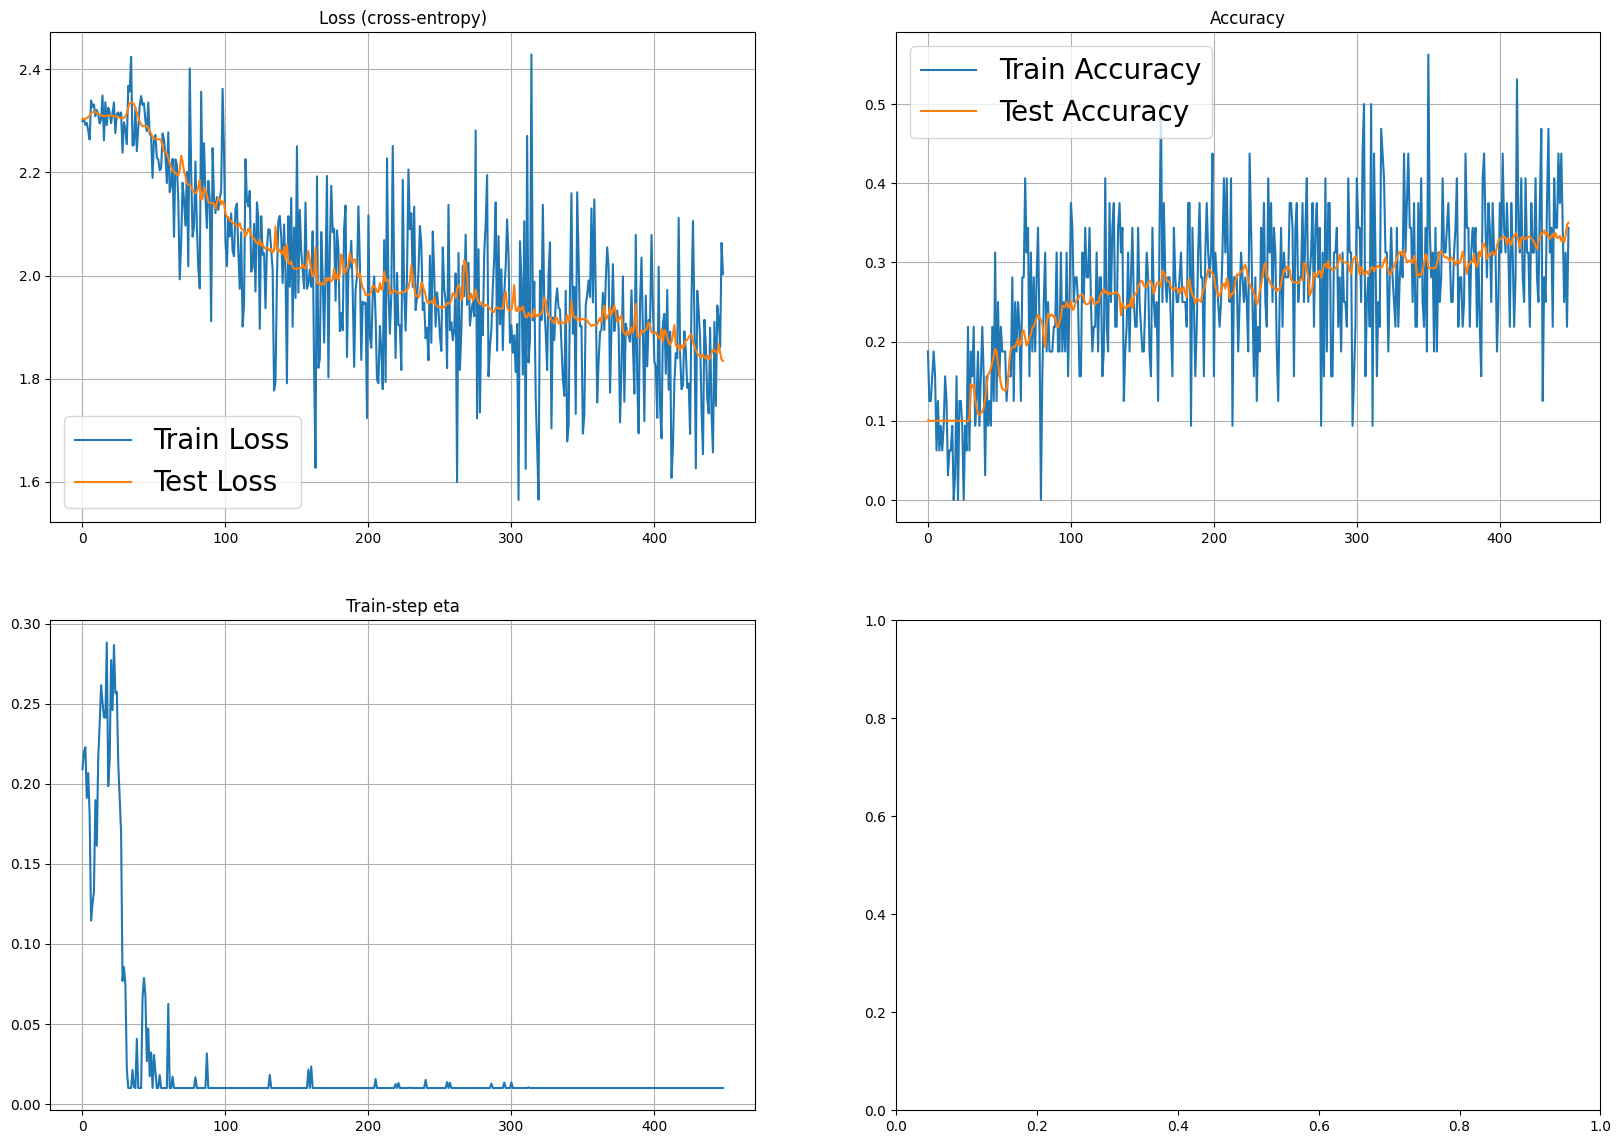

On epoch = 0 test accuracy = 0.35003993610223644


KeyboardInterrupt: 

In [13]:
#stepCalcZhL = StepCalculatorZhangLambda(meta)
#stepCalcZhS = StepCalculatorZhangSimplified(meta)
#stepCalcSoftmax1 = StepCalculatorEtaSoftmaxArmihoNorm1Base(meta)

stepCalcSoftmax2 = StepCalculatorEtaSoftmaxArmihoNorm2Base(meta)
Nesterov = True
qu = collections.deque(10*[1.0], 10)
for epoch in range(NUM_EPOCH):
    # training loop
    iter_number = 0
    for train_batch in train_dataloader:
        #testNet.train()
        testNet.do_dropout = False
        iter_number += 1
        momentum = 0.9
        #if np.average(qu) < 0.1:
        #    momentum = 0.9
        images, labels = train_batch
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        xx = images

        with torch.no_grad():
            logits = testNet.forward_(xx)
            logits_detached = logits.detach().numpy()
            pp = labels_to_softhot(labels, meta.output_dim)
            qq = softmax(np.transpose(logits_detached), axis=(0)) + 1e-8
            qq_active = reduce_to_active(qq, pp)
        qq_active_avg = np.average(qq_active)
        logging.info("##\n --==Initial qq for ones: min={}, max={}, avg={}; momentum={}, Nesterov={}==--"\
                        .format(np.min(qq_active), np.max(qq_active), qq_active_avg, momentum, Nesterov))
        #if qq_active_avg > 0.3:
        logging.info("##Step with Softmax2 optim")
        eta, logits_latest = stepCalcSoftmax2.step(testNet, labels, xx, momentum, Nesterov) #, logits_detached
        qu.appendleft(eta)

        # calculate current average loss and accuracy
        zz_logits = np.transpose(logits_latest.numpy())
        prediction = logits_latest.argmax(dim=-1)
        loss = loss_crossentropy(zz_logits, labels)
        # save average train loss and accuracy
        HISTORY_PARAMS_N2LAMBDA['train_loss'].append(loss)
        HISTORY_PARAMS_N2LAMBDA['train_accuracy'].append(calculate_accuracy(prediction,labels))
        HISTORY_PARAMS_N2LAMBDA['train_eta'].append(eta)

        # testing loop
        testNet.do_dropout = False
        test_loss_meter, test_accuracy_meter = AverageMeter(), AverageMeter()
        #testNet.eval()
        for test_batch in test_dataloader:
            images, labels = test_batch
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)
            with torch.no_grad():
                xx = images
                logits = testNet.forward_(xx)

                zz_logits = np.transpose(logits.detach().numpy())
                prediction = logits.argmax(dim=-1).detach()
                loss = loss_crossentropy(zz_logits, labels)
                test_loss_meter.update(loss)
                test_accuracy_meter.update(calculate_accuracy(prediction, labels))

        # save average test accuracy loss and accuracy
        HISTORY_PARAMS_N2LAMBDA['test_loss'].append(test_loss_meter.avg)
        HISTORY_PARAMS_N2LAMBDA['test_accuracy'].append(test_accuracy_meter.avg)
        
        visualise(HISTORY_PARAMS_N2LAMBDA)
        print("On epoch = {} test accuracy = {}".format(epoch, test_accuracy_meter.avg))



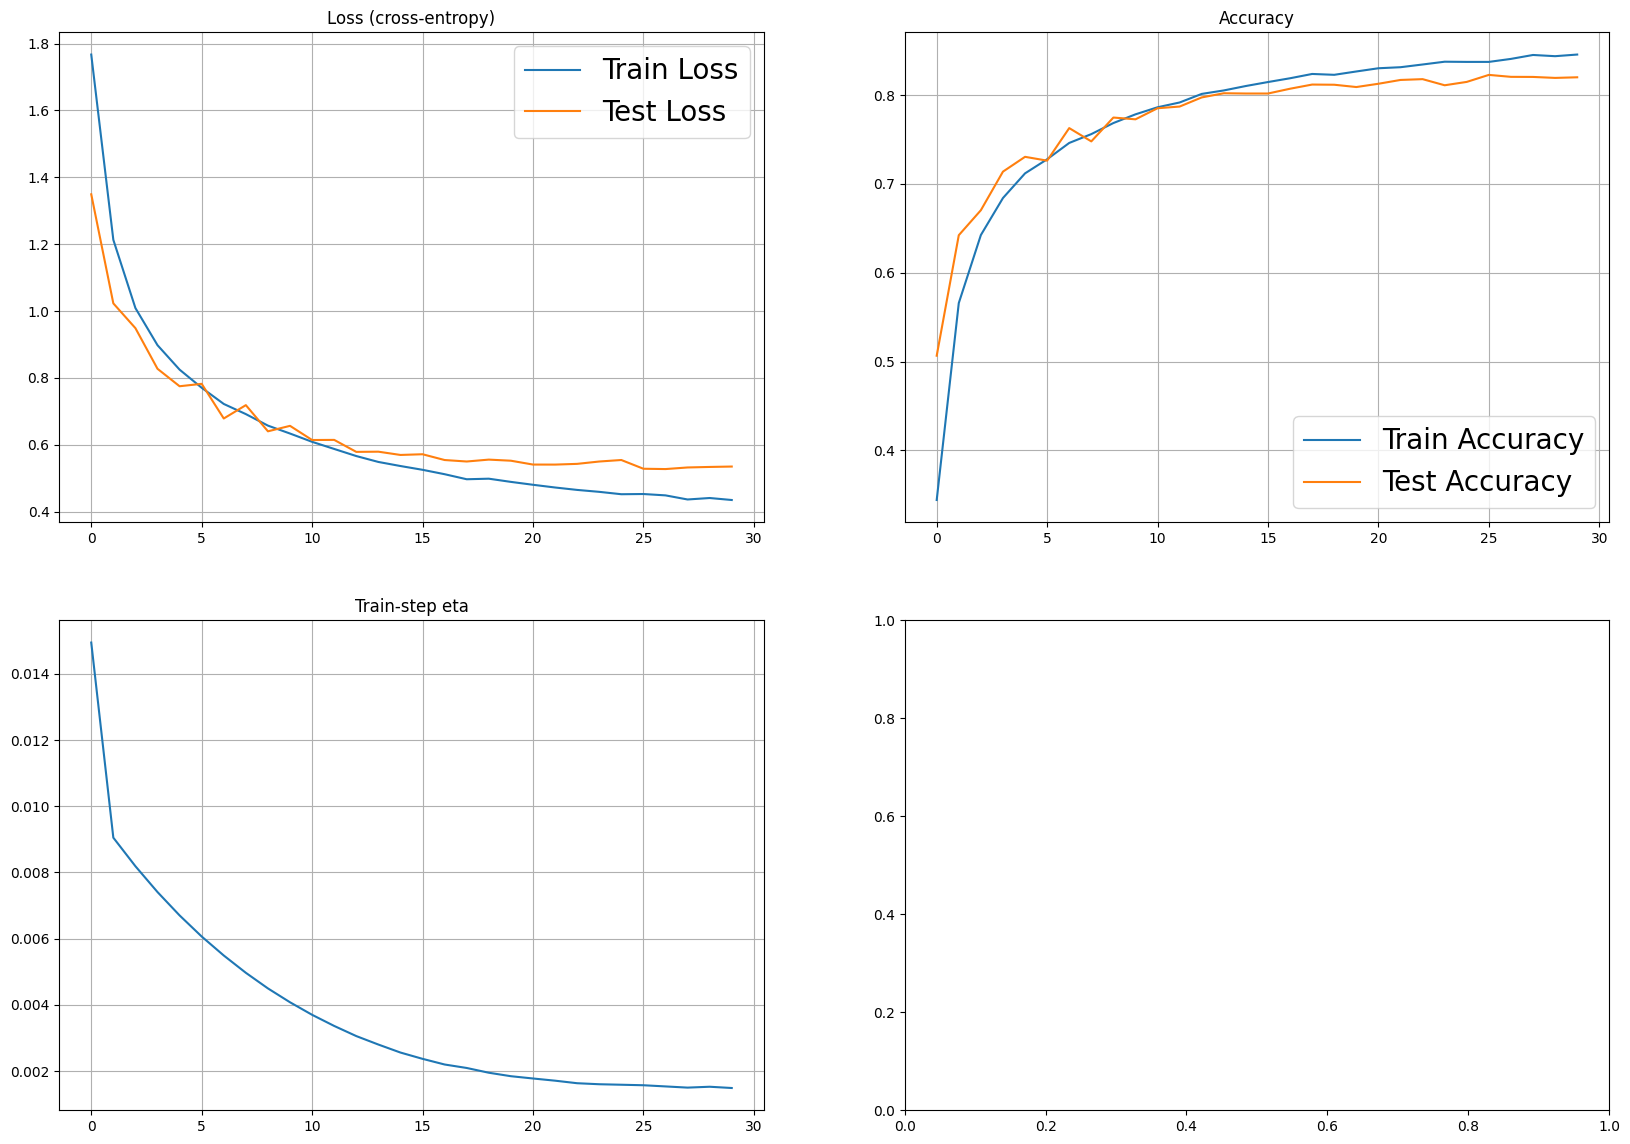

On epoch = 29 test accuracy = 0.8200878594249201


In [14]:
HISTORY_PARAMS_N2LAMBDA = collections.defaultdict(list)
NUM_EPOCH = 30

testNet = CIFAR10ReLU()
testNet.set_slopes(slope_plus, slope_minus)
#testNet.init_weights(cb, cw)
testNet.do_dropout = False
testNet.to(DEVICE)
Nesterov = True
base_min = 0.01

#stepCalcZhL = StepCalculatorZhangLambda(meta)
#stepCalcZhS = StepCalculatorZhangSimplified(meta)
#stepCalcSoftmax1 = StepCalculatorEtaSoftmaxArmihoNorm1Base(meta)
qu = collections.deque(10*[1.0], 10)
stepCalcSoftmax2 = StepCalculatorEtaSoftmaxArmihoNorm2Base(meta)
for epoch in range(NUM_EPOCH):
    stepCalcSoftmax2.eta_min = base_min * math.exp(-0.1*epoch) #base_min/(1+epoch)
    # training loop
    train_loss_meter, train_accuracy_meter, train_eta_meter = AverageMeter(), AverageMeter(), AverageMeter()
    iter_number = 0
    testNet.do_dropout = True
    testNet.train()
    for train_batch in train_dataloader:
        iter_number += 1
        logging.info("##\n --==Epoch={}, iter_number={}, eta_min={}==--"\
                     .format(epoch, iter_number, stepCalcSoftmax2.eta_min))        
        images, labels = train_batch
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        xx = images
        momentum = 0.9
        #if np.average(qu) < 0.1:
        #    momentum = 0.9

        with torch.no_grad():
            logits = testNet.forward_(xx)
            logits_detached = logits.detach().numpy()
            pp = labels_to_softhot(labels, meta.output_dim)
            qq = softmax(np.transpose(logits_detached), axis=(0)) + 1e-8
            qq_active = reduce_to_active(qq, pp)
        qq_active_avg = np.average(qq_active)
        logging.info("##\n --==Initial qq for ones: min={}, max={}, avg={}==--"\
                        .format(np.min(qq_active), np.max(qq_active), qq_active_avg))
        #if qq_active_avg > 0.3:
        logging.info("##Step with Softmax2 optim")
        #logging.info("##Logits: {}".format(logits_detached))
        eta, logits_latest = stepCalcSoftmax2.step(testNet, labels, xx, momentum, Nesterov)#, logits_detached
        #else:

        # calculate current average loss and accuracy
        zz_logits = np.transpose(logits_latest.numpy())
        prediction = logits_latest.argmax(dim=-1)
        loss = loss_crossentropy(zz_logits, labels)
        train_loss_meter.update(loss)
        train_accuracy_meter.update(calculate_accuracy(prediction,labels))
        train_eta_meter.update(eta)

    # save average train loss and accuracy
    HISTORY_PARAMS_N2LAMBDA['train_loss'].append(train_loss_meter.avg)
    HISTORY_PARAMS_N2LAMBDA['train_accuracy'].append(train_accuracy_meter.avg)
    HISTORY_PARAMS_N2LAMBDA['train_eta'].append(train_eta_meter.avg)

    # testing loop
    test_loss_meter, test_accuracy_meter = AverageMeter(), AverageMeter()
    #testNet.eval()
    testNet.do_dropout = False
    for test_batch in test_dataloader:
        images, labels = test_batch
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        with torch.no_grad():
            xx = images
            logits = testNet.forward_(xx)

            zz_logits = np.transpose(logits.detach().numpy())
            prediction = logits.argmax(dim=-1).detach()
            loss = loss_crossentropy(zz_logits, labels)
            test_loss_meter.update(loss)
            test_accuracy_meter.update(calculate_accuracy(prediction, labels))

    # save average test accuracy loss and accuracy
    HISTORY_PARAMS_N2LAMBDA['test_loss'].append(test_loss_meter.avg)
    HISTORY_PARAMS_N2LAMBDA['test_accuracy'].append(test_accuracy_meter.avg)
    
    visualise(HISTORY_PARAMS_N2LAMBDA)
    print("On epoch = {} test accuracy = {}".format(epoch, test_accuracy_meter.avg))




In [ ]:
def init_weights_copy(net, params):
    net.init_linear_zeros(net.conv1, True)
    net.init_linear_zeros(net.conv2, True)
    net.init_linear_zeros(net.conv3, True)
    net.init_linear_zeros(net.conv4, True)
    net.init_linear_zeros(net.linear5, True)
    net.init_linear_zeros(net.linear6, True)
    with torch.no_grad():
        net.conv1.weight += torch.from_numpy(params['conv1.weight'])
        net.conv1.bias += torch.from_numpy(params['conv1.bias'])
        net.conv2.weight += torch.from_numpy(params['conv2.weight'])
        net.conv2.bias += torch.from_numpy(params['conv2.bias'])
        net.conv3.weight += torch.from_numpy(params['conv3.weight'])
        net.conv3.bias += torch.from_numpy(params['conv3.bias'])
        net.conv4.weight += torch.from_numpy(params['conv4.weight'])
        net.conv4.bias += torch.from_numpy(params['conv4.bias'])
        net.linear5.weight += torch.from_numpy(params['linear5.weight'])
        net.linear5.bias += torch.from_numpy(params['linear5.bias'])
        net.linear6.weight += torch.from_numpy(params['linear6.weight'])
        net.linear6.bias += torch.from_numpy(params['linear6.bias']) 


In [ ]:
class ParameterProcessor:
    def __init__(self):
        self.theta_current = {}
        self.delta_current = {}
        self.grad_current = {}

    def is_delta_empty(self):
        return len(self.delta_current) <= 0

    def save_theta(self, model):
        with torch.no_grad():        
            for name, param in model.named_parameters():
                self.theta_current[name] = param.detach().clone()

    def set_theta(self, model, momentum, eta, eta_scale = 1.0):
        with torch.no_grad():
            for name, param in model.named_parameters():
                grad = self.grad_current[name]
                delta = self.delta_current.get(name, None)
                if momentum <= 0.0 and eta_scale > 0.0:
                    param.data.copy_(self.theta_current[name] -eta * eta_scale * grad)
                elif eta_scale <= 0.0 and momentum > 0.0:
                    if delta is not None:
                        param.data.copy_(self.theta_current[name] + momentum * delta)
                    else:
                        param.data.copy_(self.theta_current[name])
                elif eta_scale > 0.0 and momentum > 0.0:
                    if delta is not None:
                        param.data.copy_(self.theta_current[name] + momentum * delta - eta * eta_scale * grad)
                    else:
                        param.data.copy_(self.theta_current[name] - eta * eta_scale * grad)
                else:
                    raise ValueError("eta_scale or momentum must be in interval(0., 1.)")

    def save_delta_current(self, momentum, eta, eta_scale = 1.0):
        for name, grad in self.grad_current.items():
            delta = self.delta_current.get(name, None)
            if delta is None or momentum <= 0.0:
                self.delta_current[name] = -eta * eta_scale * grad
            else:
                self.delta_current[name] = momentum * delta - eta * eta_scale * grad

    #Grad optionally multiplird by lambda
    def calc_autograd(self, model, loss, lambda_dict=None):
        param_buffer ={}
        for name, param in model.named_parameters():
            param_buffer[name] = param        
        df = torch.autograd.grad(loss, param_buffer.values(), retain_graph=True, create_graph=True, allow_unused=True)
        ii = 0
        for name in param_buffer:
            lambda_value = lambda_dict.get(name, 1.) if lambda_dict is not None else 1.
            self.grad_current[name] = lambda_value * df[ii].detach().clone()
            ii += 1
    

class StepCalculatorEtaSoftmaxArmihoNorm2BasePrelib:
    def __init__(self, meta, momentum=0.9, lbd_dict=None):
        self.meta = meta
        self.momentum = momentum
        self.step_one = 1.0
        #self.step_deltas = [0.0]
        self.step_deltas = [0.0, -0.5, -0.25, -0.125, -0.0625, -0.03125, -0.015625, -0.015625]
        #self.step_deltas = [3.0, -2.0, -1.0, -0.5, -0.25, -0.125, -0.0625, -0.03125, -0.015625]
        #self.step_deltas = [1.0, -1.0, -0.5, -0.25, -0.125, -0.0625, -0.03125, -0.015625]
        self.c1 = 0.0 #0.000000005 #0.000005 #0.000025
        self.c2 = 0.99 #0.75 #0.5#
        self.c3 = 0.99

        self.epsilon = 1e-8
        self.epsilon_criteria = 1e-5
        self.eta_min = 0.001 #1e-09
        #self.eta_max = 0.25 #1e-09
        self.lbd_dict = lbd_dict
        self.criterion = nn.CrossEntropyLoss() #(reduction='sum')
        self.paramProcessor = ParameterProcessor()

    def calc_eta(self, testNet, xx, pp, qq):
        meta = self.meta
        delta = pp - qq
        delta0 = reduce_to_active(delta, pp)

        logging.info("##Calculating reduced NTK")
        params = {k: v.detach() for k, v in testNet.named_parameters()}
        fnet_single = lambda params, x: functional_call(testNet, params, (x.unsqueeze(0),)).squeeze(0)
        fnet_mul = lambda params, x: functional_call(testNet, params, (x,))
        #Reduced NTK
        #delta_r = ntkvp_np(fnet_single, params, xx, xx, delta, self.lbd_dict)
        do_dropout_val = testNet.do_dropout
        testNet.do_dropout = False
        delta_r = ntkvp2_np(fnet_single, fnet_mul, params, xx, xx, delta, self.lbd_dict)
        testNet.do_dropout = do_dropout_val

        logging.info("##Calculating step-forward and eta")
        NL_r = NTK_softmaxV3(delta_r, qq, meta)
        delta0_r = reduce_to_active(NL_r, pp)
        eta = solve_eta_norm2(NL_r, delta) #for all n,α
        eta_ones = solve_eta_norm2(delta0_r, delta0) #for each α only n with pp=1 is taken
        logging.info("##Calculated eta for ones = {}, general eta = {}".format(eta_ones, eta))
        return eta_ones, eta

    def step(self, testNet, labels, xx, momentum, Nesterov = False, use_ones = False):
        meta = self.meta
        logging.info("##Bias_0 step-start:{}".format(testNet.conv1.bias[0].item()))

        self.paramProcessor.save_theta(testNet)
        if momentum > 0.0 and Nesterov == True and self.paramProcessor.is_delta_empty() == False:
            self.paramProcessor.set_theta(testNet, momentum, 0., 0.)
            logging.info("##Bias_0 Nesterov pre-set:{}".format(testNet.conv1.bias[0].item()))

        with torch.no_grad():
            logits_detached = testNet.forward_(xx).detach().numpy().copy()
        pp = labels_to_softhot(labels, meta.output_dim)
        qq = softmax(np.transpose(logits_detached), axis=(0)) + self.epsilon

        eta_ones, eta = self.calc_eta(testNet, xx, pp, qq)
        if use_ones:
            eta = eta_ones
        logging.info("##Eta value = {}".format(eta))
        if eta < self.eta_min or math.isnan(eta):
            logging.info("##Eta changed from {} to {}".format(eta, self.eta_min))
            eta = self.eta_min

        logging.info("##Calculating params-delta")
        testNet.zero_grad()
        logits = testNet.forward_(xx)
        loss = self.criterion(logits, labels)
        self.paramProcessor.calc_autograd(testNet, loss, self.lbd_dict)
        logging.info("##Bias_0 calc_autograd:{}".format(self.paramProcessor.grad_current['conv1.bias'][0].item()))

        eta_scale, eta, logits_k = self.backtrack_armiho_wolf_additional(testNet, xx, pp, qq, eta, momentum)
        self.paramProcessor.save_delta_current(momentum, eta, eta_scale)
        logging.info("##Bias_0 delta:{}".format(self.paramProcessor.delta_current['conv1.bias'][0].item()))
        logging.info("##Bias_0 step-finnish:{}".format(testNet.conv1.bias[0].item()))
        return eta_scale*eta, logits_k
    
    #Armiho: Loss(θ+α) <= c1*α*∇Loss(θ) + Loss(θ)
    #Wolf: |∇Loss(θ+α)| <= c2*|∇Loss(θ)|
    #0<c1<c2<1
    #Additional condition: ∇Loss(θ+α) <= c3*|∇Loss(θ)| , 0<c3<1 (Significant loss growth at the final point is unacceptable)
    def backtrack_armiho_wolf_additional(self, testNet, xx, pp, qq, eta, momentum):
        meta = self.meta
        qq_reduced = reduce_to_active(qq, pp)
        initialLoss = -np.sum(pp * np.log(qq))/meta.batch_size
        ratio = reduce_to_active(pp/qq, pp)
        logging.info("##Initial loss = {}".format(initialLoss))

        with torch.no_grad():
            #Initial 1.0 forward
            self.paramProcessor.set_theta(testNet, momentum, eta, self.step_one)
            logging.info("##Bias_0 initial 1.0:{}".format(testNet.conv1.bias[0].item()))
            logits_one = testNet.forward_(xx)
            qq_one = softmax(np.transpose(logits_one.detach().numpy().copy()), axis=(0)) + self.epsilon
            delta_delta_one = reduce_to_active(qq - qq_one, pp) #We consider pp/qq without -

            logits_k = None
            eta_scale = self.step_one
            for step_delta in self.step_deltas:
                if (step_delta != 0.0):
                    eta_scale += step_delta
                    self.paramProcessor.set_theta(testNet, momentum, eta, eta_scale)
                    logging.info("##Bias_0 adjustment to {}:{}".format(eta_scale, testNet.conv1.bias[0].item()))
                logits_k = testNet.forward_(xx)
                qq_k = softmax(np.transpose(logits_k.detach().numpy().copy()), axis=(0)) + self.epsilon
                qq_k_reduced = reduce_to_active(qq_k, pp)
                #loss_k = -np.sum(pp * np.log(qq_k))/meta.batch_size
                loss_k = -np.sum(np.log(qq_k_reduced))/meta.batch_size
                ratio_k = reduce_to_active(pp/qq_k, pp)
                #diff_est_k = np.dot(ratio_k, delta_delta_est) #∇L(θ+α)
                logging.info("##Step with eta_scale: {}, loss = {}".format(eta_scale, loss_k))
                logging.info("##Factual qq_k for ones: min={}, max={}, avg={}"\
                             .format(np.min(qq_k_reduced), np.max(qq_k_reduced), np.average(qq_k_reduced)))
                
                diff_fact = np.dot(ratio, delta_delta_one)
                diff_fact_k = np.dot(ratio_k, delta_delta_one)
                pq_ratio_k = 1.0
                try:
                    pq_ratio_k = norm(1 - qq_k_reduced, ord=2)/norm(1 - qq_reduced, ord=2)
                except ValueError as ex:
                    logging.error("Error when (p-q)ratio norm-2 for ones calculated: {}".format(ex))
                logging.info("##With factual qq_k: diff_init = {}, diff_k = {}, (p-q)ratio norm-2 for ones: {}"\
                            .format(diff_fact, diff_fact_k, pq_ratio_k))
                condition_armiho = loss_k - self.epsilon_criteria <= initialLoss + self.c1*eta_scale*diff_fact
                condition_wolf = abs(diff_fact_k) - self.epsilon_criteria <= self.c2*abs(diff_fact)
                condition_additional = diff_fact_k - self.epsilon_criteria <= self.c3*abs(diff_fact)
                logging.info("##Conditions: armiho = {}, wolf = {}, additional = {}, "\
                             .format(condition_armiho, condition_wolf, condition_additional))
                if condition_armiho: #and condition_wolf and condition_additional:
                    break

        return eta_scale, eta, logits_k

In [ ]:
DEVICE = torch.device('cpu:0')
eta_fixed = 1e-2

testNet = CIFAR10ReLU()
testNet.set_slopes(slope_plus, slope_minus)
testNet.do_dropout = False
testNet.to(DEVICE)
#model.apply(init_weights)
params = {k: v.detach().numpy() for k, v in testNet.named_parameters()}
#save_txt(params, "tmp")
testNetPrelib = CIFAR10ReLU()
testNetPrelib.set_slopes(slope_plus, slope_minus)
testNetPrelib.do_dropout = False
testNetPrelib.to(DEVICE)
init_weights_copy(testNetPrelib, params)

stepCalcSoftmax2 = StepCalculatorEtaSoftmaxArmihoNorm2Base(meta)
stepCalcSoftmax2Prelib = StepCalculatorEtaSoftmaxArmihoNorm2BasePrelib(meta)

In [ ]:
bias0 = testNet.conv1.bias.detach().numpy().copy()
biasPrelib0 = testNetPrelib.conv1.bias.detach().numpy().copy()
weight0 = testNet.conv1.weight.detach().numpy().copy()
weightPrelib0 = testNetPrelib.conv1.weight.detach().numpy().copy()

In [ ]:
biasPrelib0-bias0

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
      dtype=float32)

In [ ]:
images, labels = next(iter(train_dataloader))
images = images.to(DEVICE)
labels = labels.to(DEVICE)

momentum = 0.9
Nesterov = True

eta, logits_latest = stepCalcSoftmax2.step(testNet, labels, images, momentum, Nesterov)
etaPrelib, logits_latestPrelib = stepCalcSoftmax2Prelib.step(testNetPrelib, labels, images, momentum, Nesterov)

In [ ]:
bias1 = testNet.conv1.bias.detach().numpy().copy()
biasPrelib1 = testNetPrelib.conv1.bias.detach().numpy().copy()
weight1 = testNet.conv1.weight.detach().numpy().copy()
weightPrelib1 = testNetPrelib.conv1.weight.detach().numpy().copy()

In [ ]:
(bias1 - biasPrelib1).sum()

0.0

In [ ]:
stepCalcSoftmax2.conv1_grad_bias
#stepCalcSoftmax2Prelib
#-eta*stepCalcSoftmax2Prelib.paramProcessor.grad_current['conv1.bias']
#etaPrelib-eta

tensor([-2.3534e-05,  1.7725e-04, -9.3796e-06, -3.2239e-05, -1.0249e-04,
        -3.1933e-05, -1.7101e-05,  3.9790e-05,  8.3413e-06, -3.2922e-04,
         1.3807e-04,  5.0945e-06,  1.0637e-04, -1.3404e-05,  3.9297e-05,
         6.9892e-05])